In [7]:
import sys
import os
import pandas as pd
sys.path.append(os.path.abspath('../src'))
from data_loader import load_data, clean_data
from modeling import prepare_data, evaluate_models

# Load cleaned version
df = load_data('../data/insurance_data.csv')
df = clean_data(df)

# Prepare and Train
X_train, X_test, y_train, y_test = prepare_data(df)
results_df, models = evaluate_models(X_train, X_test, y_train, y_test)

print("Model Comparison Table:")
print(results_df)

Model Comparison Table:
               Model         RMSE        R2
0  Linear Regression  3443.675092  0.172055
1      Random Forest  3501.415798  0.144057
2            XGBoost  3485.278901  0.151929


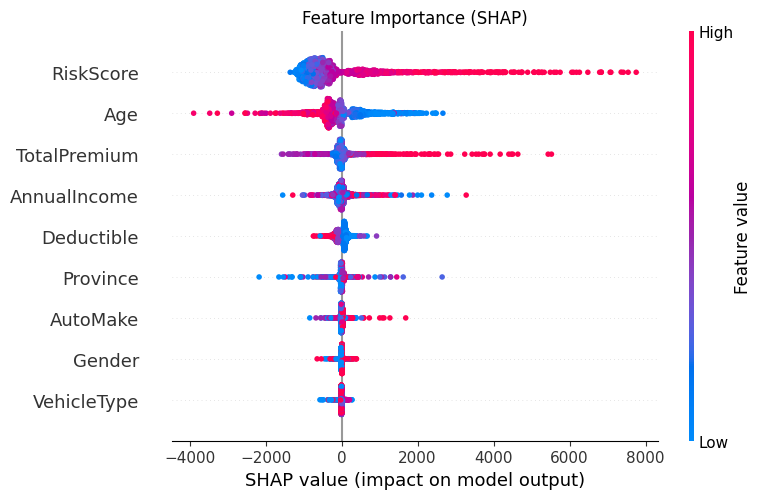

In [8]:
import shap
import matplotlib.pyplot as plt

# I use Random Forest or XGBoost for SHAP
best_model = models["XGBoost"]

# Calculate SHAP values
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# Plot
plt.title("Feature Importance (SHAP)")
shap.summary_plot(shap_values, X_test)

In [ ]:
from sklearn.preprocessing import LabelEncoder

features = ['Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 
            'RiskScore', 'TotalPremium', 'AutoMake', 'Deductible']

X_all = df[features].copy()

le = LabelEncoder()
for col in X_all.select_dtypes(include=['object']).columns:
    X_all[col] = le.fit_transform(X_all[col].astype(str))

# 3. Get predictions for all 10,000 rows
# I use the best model we trained earlier (XGBoost)
df['Predicted_Claim_Severity'] = models["XGBoost"].predict(X_all)

# 4. Calculate the Recommended Premium
# Formula: (Predicted Severity * 1.2 Risk Margin) + 50 Admin Fee
df['Recommended_Premium'] = (df['Predicted_Claim_Severity'] * 1.20) + 50

# 5. Show the results
print("Success! Smart Pricing applied to all rows.")
print(df[['TotalPremium', 'Recommended_Premium', 'TotalClaims']].head(10))

# 6. Calculate how much profit/loss the new pricing would create
new_total_premium = df['Recommended_Premium'].sum()
old_total_premium = df['TotalPremium'].sum()
print(f"\nTotal Revenue with Old Pricing: {old_total_premium:,.2f}")
print(f"Total Revenue with Smart Pricing: {new_total_premium:,.2f}")

Success! Smart Pricing applied to all rows.
   TotalPremium  Recommended_Premium  TotalClaims
0          2346           963.698364          0.0
1          2334           815.060547       9883.0
2          1697           292.286926          0.0
3          2370          2043.067749      12134.0
4          2582          1465.244873          0.0
5          1310           713.820557          0.0
6          2204           647.287292          0.0
7          1590           203.116455          0.0
8          2665           907.718872          0.0
9          2527           866.027954          0.0

Total Revenue with Old Pricing: 24,881,279.00
Total Revenue with Smart Pricing: 16,259,334.00


C:\Users\DELL 7020\AppData\Local\Temp\ipykernel_23356\3191615098.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_all.select_dtypes(include=['object']).columns:


Business Insight:
"While our A/B tests showed that Gender doesn't matter, our Machine Learning model reveals that RiskScore and Deductible are the strongest predictors of claims. ACIS should transition from demographic-based pricing to behavior-based pricing using these features."